In [62]:
import mujoco as mj
import mediapy as media
import numpy as np
import pandas as pd
import os
import sympy as sp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize

plt.rcParams.update({
    "text.usetex": False,  # Use LaTeX for all text (if available)
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": True
})


from ipywidgets import interactive_output, VBox ,widgets


In [30]:
# Parameters
scale = 0.5

# Motor coordinates
O_1x, O_2x,O_1y, O_2y = -0.075 * scale, 0.075 * scale,0 * scale, 0 * scale

# Link lengths
L_p1, L_p2, L_d1, L_d2 = [0.2 * scale, 0.2 * scale, 0.4 * scale, 0.4 * scale]

# A known configuration for the mechanism
q_base=np.vstack([-0.14571*scale,0.07071*scale,np.deg2rad(135),
     -0.10821*scale,0.30962*scale,np.deg2rad(57.244623466),
     0.10821*scale,0.30962*scale,np.deg2rad(-57.244623466),
     0.14571*scale,0.07071*scale,np.deg2rad(-135)])

# Symbolic variables
t = sp.Symbol('t')

phi_p1, phi_p2, phi_d1, phi_d2 = sp.symbols('phi_p1 phi_p2 phi_d1 phi_d2')
x_p1, y_p1, x_p2, y_p2 = sp.symbols('x_p1 y_p1 x_p2 y_p2')
x_d1, y_d1, x_d2, y_d2 = sp.symbols('x_d1 y_d1 x_d2 y_d2')
sym_phi_p1 = sp.Function('sym_phi_p1')(t)
sym_phi_p2 = sp.Function('sym_phi_p2')(t)
phi_p1_dot, phi_p2_dot = sp.symbols('phi_p1_dot phi_p2_dot')


# Rotation matrix function (symbolic and numeric)
def rotmat(phi):
    return sp.Matrix([[sp.cos(phi), -sp.sin(phi)], [sp.sin(phi), sp.cos(phi)]])

def rotmat_num(phi):
    return np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])

# Generalized coordinates vector
q = sp.Matrix([x_p1, y_p1, phi_p1, x_d1, y_d1, phi_d1, x_d2, y_d2, phi_d2, x_p2, y_p2, phi_p2])

# Number of generalized coordinates
nq=len(q)

# The inverse is defined as a symolic variable to avoid the analytical calculation of the inverse of the jacobian
inv_PHI_q=sp.MatrixSymbol('inv_PHI_q', nq, nq)

# Joint equations
# Proximal link 1 - Ground
eq1 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([-L_p1 / 2, 0]) - sp.Matrix([O_1x, O_1y])

# Proximal link 1 - Distal Link 1
eq2 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([L_p1 / 2, 0]) - (sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([-L_d1 / 2, 0]))

#  Proximal link 1 - Distal Link 1
eq3 = sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0]) - (sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([-L_d2 / 2, 0]))

# Distal Link 2 - Proximal Link 2
eq4 = sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([L_d2 / 2, 0]) - (sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([-L_p2 / 2, 0]))

# Proximal Link 2 - Ground
eq5 = sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([L_p2 / 2, 0]) - sp.Matrix([O_2x, O_2y])

# Actuation Equations
eq6 = sp.Matrix([phi_p1, phi_p2]) - sp.Matrix([sym_phi_p1, sym_phi_p2])

# Constraint vector
PHI = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6))

# Calculates Jacobian
PHI_q = PHI.jacobian(q)
dq_eq=-inv_PHI_q@PHI.diff(t)

dq_eq_subs = dq_eq.subs({
    sp.Derivative(sym_phi_p1, t): phi_p1_dot,
    sp.Derivative(sym_phi_p2, t): phi_p2_dot
})

# Convert symbolic expressions to numerical functions
PHI_fun = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI, 'numpy')
PHI_q_fun = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_q, 'numpy')
dq_fun = sp.lambdify((q, t, inv_PHI_q, phi_p1_dot, phi_p2_dot), dq_eq_subs, 'numpy')

In [31]:
def distal_relative_angles_from_proximal(q_0,theta1,theta2,dtheta1,dtheta2):
    # Newton - Rhapson Solver Parameters
    tol=1e-6
    max_iters=100
 
    j=1 # Reset iteration counter
    q_ant=q_0 # Pick random solution from the ones solved
    q_0=np.vstack(q_ant) # Use random solution as the initial guess for the next iteration
    
    while True:

        phi_val=PHI_fun(q_0.flatten(),theta1,theta2)
        
        inv_phi_q_val=np.linalg.inv(PHI_q_fun(q_0.flatten(),theta1,theta2))
        
        q_1=q_0-inv_phi_q_val@phi_val
        
        if j>max_iters:
            return None
        
        if max(abs(phi_val))<=tol:
            
            q_sol=q_0
            theta3=q_sol.flatten()[5]-q_sol.flatten()[2]
            theta4=q_sol.flatten()[8]-q_sol.flatten()[11]
            
            dq_sol = dq_fun(q_sol, 0, inv_phi_q_val, dtheta1, dtheta2)
            
            dtheta3=dq_sol.flatten()[5]-dq_sol.flatten()[2]
            dtheta4=dq_sol.flatten()[8]-dq_sol.flatten()[11]

            return theta3,theta4,dtheta3,dtheta4
        q_0=q_1
        j+=1

In [32]:
df=pd.read_csv(os.path.join("data",'robot_data_final.csv'))
unique_series = df['series_id'].unique()
print(unique_series)

df.head()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]


,time,series_id,angle1,angle2,speed1,speed2,torque1,torque2,target1,target2
0,0.000000,0,135,-135,0,0,0.0810,-0.018,135.0,-135.0
1,0.010998,0,135,-135,0,0,0.0900,-0.027,135.0,-135.0
2,0.021208,0,135,-135,0,0,0.0135,0.000,135.0,-135.0
3,0.032248,0,134,-134,-5,0,0.0045,-0.009,135.0,-135.0
4,0.043206,0,134,-134,-10,5,-0.0045,0.000,135.0,-135.0


In [33]:
column_groups = {
    'angle': ('angle1', 'angle2'),
    'speed': ('speed1', 'speed2'),
    'torque': ('torque1', 'torque2')
}

grouped = df.groupby('series_id')

# Define widgets
series_idx_slider = widgets.IntSlider(
    value=0, min=0, max=len(unique_series)-1, step=1,
    description='Series Index'
)
variable_group_dropdown = widgets.Dropdown(
    options=['angle', 'speed', 'torque'],
    value='angle',
    description='Variable'
)

# Update the function to accept actual values
def plot_series_optimized(series_idx, variable_group):
    series_id = unique_series[series_idx]
    subset = grouped.get_group(series_id)  # Faster access
    col1, col2 = column_groups[variable_group]

    plt.figure(figsize=(10, 5))
    plt.plot(subset['time'], subset[col1], label=col1, marker='o')
    plt.plot(subset['time'], subset[col2], label=col2, marker='x')
    plt.xlabel('Time')
    plt.ylabel(variable_group.capitalize())
    plt.title(f'{variable_group.capitalize()} for Series ID: {series_id}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Hook widgets to function
out = interactive_output(plot_series_optimized, {
    'series_idx': series_idx_slider,
    'variable_group': variable_group_dropdown
})

# Display
VBox([series_idx_slider, variable_group_dropdown, out])

In [34]:
def generate_mujoco_xml(timestep,o1x,o1y,o2x,o2y,L_p1,L_p2,L_d1,L_d2,link_width,link_height,link_separation,rotor1_D,rotor2_D,rotor1_H,rotor2_H,
                        max_torque,q0,
                        inertia_rotor1,inertia_rotor2,inertia_p1,inertia_p2,inertia_d1,inertia_d2,
                        com_offset_p1,com_offset_p2,com_offset_d1,com_offset_d2,
                        mass_rotor1,mass_rotor2,mass_p1,mass_p2,mass_d1,mass_d2,
                        damping_bp1,damping_bp2,damping_p1d1,damping_p2d2,
                        dryfrict_bp1,dryfrict_bp2,dryfrict_p1d1,dryfrict_p2d2):
    xml_template = f"""
<mujoco model="parallel_5_bar_mechanism">
    <compiler angle="degree"/>
    <option gravity="0 0 -9.81" integrator="RK4" timestep="{timestep}" />
    <asset>
        <texture type="skybox" builtin="gradient" rgb1=".4 .5 .6" rgb2="0 0 0" width="100" height="100"/>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3" rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <light cutoff="100" diffuse="1 1 1" dir="-0 0 -1.3" directional="true" exponent="1" pos="0 0 1.3" specular=".1 .1 .1"/>
        <geom name="worldbody" size="1 1 .01" pos="0 0 -.2" type="plane" material="grid"/>
        <body name="base" pos="0 0 0">
            <body name="proximal1" pos="{o1x} {o1y} {1.5*link_height+1.5*link_separation}" euler="0 0 {np.rad2deg(q0[0])}">
                <inertial pos='{L_p1/2+com_offset_p1} 0 0' mass='{mass_p1}' diaginertia='{inertia_p1} {inertia_p1} {inertia_p1}'/>
                <body name="rotor1" pos="0 0 {rotor1_H/2+link_height/2}"> 
                    <geom type="cylinder" size="{rotor1_D/2} {rotor1_H/2}" rgba="0 0 0 1"/>
                    <inertial pos="0 0 0" mass="{mass_rotor1}" diaginertia='{inertia_rotor1} {inertia_rotor1} {inertia_rotor1}' />
                </body>
                <joint name="joint1" type="hinge" axis="0 0 1" pos="0 0 0"   damping="{damping_bp1}" frictionloss="{dryfrict_bp1}" stiffness="0" ref="{np.rad2deg(q0[0])}"/>
                <geom name="proximal1" type="box" size="{(L_p1)/2} {link_width/2} {link_height/2}" pos="{L_p1/2} 0 0" rgba="1 0 0 1"/>
                <body name="distal1" pos="{L_p1} 0 {-link_height-link_separation}" euler="0 0 {np.rad2deg(q0[1]-q0[0])}">
                    <inertial pos='{L_d1/2+com_offset_d1} 0 0' mass='{mass_d1}' diaginertia='{inertia_d1} {inertia_d1} {inertia_d1}'/>
                    <joint name="joint3" type="hinge" axis="0 0 1" pos="0 0 0"  damping="{damping_p1d1}" frictionloss="{dryfrict_p1d1}" stiffness="0" ref="{np.rad2deg(q0[1]-q0[0])}"/>
                    <geom name="distal1" type="box" size="{L_d1/2} {link_width/2} {link_height/2}" pos="{L_d1/2} 0 0" rgba="0 1 0 1"/>
                    <body name="end_effector" pos="{L_d1} 0 0">
					    <geom contype="0" name="end_effector" pos="0 0 0" rgba="0.0 0.8 0.6 1" size=".001" type="sphere"/>
				    </body>
                </body>
            </body>
            <body name="proximal2" pos="{o2x} {o2y} {-1.5*link_height-1.5*link_separation}" euler="0 0 {np.rad2deg(q0[3])}">
                <inertial pos='{-L_p2/2+com_offset_p2} 0 0' mass='{mass_p2}' diaginertia='{inertia_p2} {inertia_p2} {inertia_p2}'/>
                <body name="rotor2" pos="0 0 -{rotor2_H/2+link_height/2}"> 
                    <geom type="cylinder" size="{rotor2_D/2} {rotor2_H/2}" rgba="0 0 0 1"/>
                    <inertial pos="0 0 0" mass="{mass_rotor2}" diaginertia='{inertia_rotor2} {inertia_rotor2} {inertia_rotor2}' />
                </body>
                <joint name="joint2" type="hinge" axis="0 0 1" pos="0 0 0"  damping="{damping_bp2}" frictionloss="{dryfrict_bp2}" stiffness="0"  ref="{np.rad2deg(q0[3])}"/>
                <geom name="proximal2" type="box" size="{L_p2/2} {(link_width)/2} {link_height/2}" pos="{-L_p2/2} 0 0" rgba="1 0 0 1"/>
                <body name="distal2" pos="{-L_p2} 0 {link_height+link_separation}" euler="0 0 {np.rad2deg(q0[2]-q0[3])}">
                    <inertial pos='{-L_d2/2+com_offset_d2} 0 0' mass='{mass_d2}' diaginertia='{inertia_d2} {inertia_d2} {inertia_d2}'/>
                    <joint name="joint4" type="hinge" axis="0 0 1" pos="0 0 0"  damping="{damping_p2d2}" frictionloss="{dryfrict_p2d2}" stiffness="0" ref="{np.rad2deg(q0[2]-q0[3])}"/>
                    <geom name="distal2" type="box" size="{L_d2/2} {link_width/2} {link_height/2}" pos="{-L_d2/2} 0 0" rgba="0 1 0 1"/>
                </body>
            </body>
        </body>
        <body name="target" pos=".125 .125 0">
			<joint armature="0" axis="1 0 0" damping="0" limited="true" name="target_x" pos="0 0 0" range="-1 1" ref=".125" stiffness="0" type="slide"/>
			<joint armature="0" axis="0 1 0" damping="0" limited="true" name="target_y" pos="0 0 0" range="-1 1" ref=".125" stiffness="0" type="slide"/>
			<geom conaffinity="0" contype="0" name="target" pos="0 0 0" rgba="0.9 0.2 0.2 1" size="0.01" type="sphere"/>
	    </body>
    </worldbody>
    <equality>
		<connect anchor="{L_d1} 0 0" body1="distal1" body2="distal2" name="equality_constraint"/>
	</equality>
    <sensor>
		<framepos objtype="body" objname="end_effector"/>
		<framelinvel objtype="body" objname="end_effector"/>
	</sensor>
    <actuator>
        <!position joint="joint1" ctrllimited="true"  ctrlrange="0 3.14" kp="3" kv="0.1"/>
        <!position joint="joint2" ctrllimited="true"  ctrlrange="-3.14 0" kp="3" kv="0.1"/>
        <motor joint="joint1" ctrllimited="true"  ctrlrange="-{max_torque} {max_torque}"/>
        <motor joint="joint2" ctrllimited="true"  ctrlrange="-{max_torque} {max_torque}"/>
    </actuator>
</mujoco>
"""
    param_str="timestep,o1x,o1y,o2x,o2y,L_p1,L_p2,L_d1,L_d2,link_width,link_height,link_separation,rotor1_D,rotor2_D,rotor1_H,rotor2_H,max_torque,q0,inertia_rotor1,inertia_rotor2,inertia_p1,inertia_p2,inertia_d1,inertia_d2,com_offset_p1,com_offset_p2,com_offset_d1,com_offset_d2,mass_rotor1,mass_rotor2,mass_p1,mass_p2,mass_d1,mass_d2,damping_bp1,damping_bp2,damping_p1d1,damping_p2d2,dryfrict_bp1,dryfrict_bp2,dryfrict_p1d1,dryfrict_p2d2"
    param_str_list=param_str.split(",")
    params=[timestep,o1x,o1y,o2x,o2y,L_p1,L_p2,L_d1,L_d2,link_width,link_height,link_separation,rotor1_D,rotor2_D,rotor1_H,rotor2_H,max_torque,q0,inertia_rotor1,inertia_rotor2,inertia_p1,inertia_p2,inertia_d1,inertia_d2,com_offset_p1,com_offset_p2,com_offset_d1,com_offset_d2,mass_rotor1,mass_rotor2,mass_p1,mass_p2,mass_d1,mass_d2,damping_bp1,damping_bp2,damping_p1d1,damping_p2d2,dryfrict_bp1,dryfrict_bp2,dryfrict_p1d1,dryfrict_p2d2]
    for i in range(len(params)):
        print(param_str_list[i]+"="+str(params[i]))
    return xml_template

In [35]:
def simplified_xml(offset_p,offset_d,inertia_p,inertia_d,inertia_rotor,dry_friction_pd,dry_friction_motor1,dry_friction_motor2,damping_pd,damping_motor1,damping_motor2):
    timestep=0.01
    scale=0.5
    o1x=-0.075*scale
    o1y=0*scale
    o2x=0.075*scale
    o2y=0*scale
    L_p1=0.2*scale
    L_p2=0.2*scale
    L_d1=0.4*scale
    L_d2=0.4*scale
    link_width=0.02
    link_height=0.026
    link_separation=0.003
    max_torque=1.6

    q0=[2.356194490192345,
        0.999107158546108,
        -0.999107158546108,
        -2.356194490192345]

    
    inertia_p1=inertia_p
    inertia_p2=inertia_p
    inertia_d1=inertia_d
    inertia_d2=inertia_d

    mass_p=147.2e-3
    mass_d=193.4e-3
    
    mass_p1=mass_p
    mass_p2=mass_p
    
    mass_d1=mass_d
    mass_d2=mass_d

    damping_bp1=damping_motor1
    damping_bp2=damping_motor2
    damping_p1d1=damping_pd
    damping_p2d2=damping_pd

    dryfrict_bp1=dry_friction_motor1
    dryfrict_bp2=dry_friction_motor2
    dryfrict_p1d1=dry_friction_pd
    dryfrict_p2d2=dry_friction_pd

    rotor1_D=89e-3# From Motor Spec
    rotor2_D=rotor1_D
    rotor1_H=28e-3# From Motor Spec
    rotor2_H=rotor1_H
    
    
    inertia_rotor1=inertia_rotor
    inertia_rotor2=inertia_rotor

    mass_rotor1=0.65
    mass_rotor2=mass_rotor1

    com_offset_p1=offset_p
    com_offset_p2=-offset_p
    
    com_offset_d1=offset_d
    com_offset_d2=-offset_d
    
    return generate_mujoco_xml(timestep,o1x,o1y,o2x,o2y,L_p1,L_p2,L_d1,L_d2,link_width,link_height,link_separation,rotor1_D,rotor2_D,rotor1_H,rotor2_H,
                        max_torque,q0,
                        inertia_rotor1,inertia_rotor2,inertia_p1,inertia_p2,inertia_d1,inertia_d2,
                        com_offset_p1,com_offset_p2,com_offset_d1,com_offset_d2,
                        mass_rotor1,mass_rotor2,mass_p1,mass_p2,mass_d1,mass_d2,
                        damping_bp1,damping_bp2,damping_p1d1,damping_p2d2,
                        dryfrict_bp1,dryfrict_bp2,dryfrict_p1d1,dryfrict_p2d2)

In [36]:
interpolation_fcns=[]

for series in df['series_id'].unique():
    current_series=df[df['series_id']==series]
    interpolation_fcns.append({"torque1":interp1d(current_series['time'], current_series['torque1'], kind='linear', fill_value='extrapolate'),
                               "torque2":interp1d(current_series['time'], current_series['torque2'], kind='linear', fill_value='extrapolate'),
                               "angle1":interp1d(current_series['time'], current_series['angle1'], kind='linear', fill_value='extrapolate'),
                               "angle2":interp1d(current_series['time'], current_series['angle2'], kind='linear', fill_value='extrapolate'),

                               "speed1":interp1d(current_series['time'], current_series['speed1'], kind='linear', fill_value='extrapolate'),
                               "speed2":interp1d(current_series['time'], current_series['speed2'], kind='linear', fill_value='extrapolate')})
    
interpolation_fcns=interpolation_fcns[1:]

In [49]:

offset_p=-1e-3
offset_d=0

inertia_p=0.00038976
inertia_d=0.00158076

dry_friction_pd=0
damping_pd=0

dry_friction_motor1=0
dry_friction_motor2=0

damping_motor1=0
damping_motor2=0

inertia_rotor=0.0003271

 #from motor spec

xml=simplified_xml(offset_p,offset_d,inertia_p,inertia_d,inertia_rotor,dry_friction_pd,dry_friction_motor1,dry_friction_motor2,damping_pd,damping_motor1,damping_motor2)

model = mj.MjModel.from_xml_string(xml)
data = mj.MjData(model)


# enable joint visualization option:
scene_option = mj.MjvOption()
cam = mj.MjvCamera()
cam.type = mj.mjtCamera.mjCAMERA_FREE
cam.fixedcamid = -1  # Free camera mode
cam.distance = 0.75   # Distance from lookat point
cam.azimuth = 90      # Rotation around vertical axis (0 for straight)
cam.elevation = -90  # -90 looks straight down
cam.lookat = np.array([0.0, 0.0, 0.0])

duration = 2  # (seconds)
framerate = 60  # (Hz)

sim_dataframes=[]

for fcns in interpolation_fcns:
    # Simulate and display video.
    frames = []
    mj.mj_resetData(model, data)
    
    theta1_0=np.deg2rad(fcns["angle1"](0))
    theta2_0=np.deg2rad(fcns["angle2"](0))
    
    dtheta1_0=np.deg2rad(fcns["speed1"](0))
    dtheta2_0=np.deg2rad(fcns["speed2"](0))

    theta3_0,theta4_0,dtheta3_0,dtheta4_0=distal_relative_angles_from_proximal(q_base,theta1_0,theta2_0,dtheta1_0,dtheta2_0)
    
    data.qpos[0] = theta1_0
    data.qpos[2] = theta2_0
    
    data.qpos[1] = theta3_0
    data.qpos[3] = theta4_0
    
    data.qvel[0] = dtheta1_0
    data.qvel[2] = dtheta2_0
    
    data.qvel[1] = 0
    data.qvel[3] = 0

    mj.mj_forward(model, data)

    sim_df=pd.DataFrame(columns=['time', 'angle1', 'angle2','speed1','speed2'])

    with mj.Renderer(model) as renderer:
        while data.time < duration:

            new_row = {
            'time': data.time,
            'angle1': np.rad2deg(data.qpos[0]),
            'angle2': np.rad2deg(data.qpos[2]),
            'speed1': np.rad2deg(data.qvel[0]),
            'speed2': np.rad2deg(data.qvel[2])
            }

            sim_df.loc[len(sim_df)]=new_row

            data.ctrl[0]=fcns["torque1"](data.time)
            data.ctrl[1]=fcns["torque2"](data.time)
            mj.mj_step(model, data)

            if len(frames) < data.time * framerate:
                renderer.update_scene(data, scene_option=scene_option, camera=cam)
                pixels = renderer.render()
                frames.append(pixels)
    sim_dataframes.append(sim_df)
    #media.show_video(frames, fps=framerate)


timestep=0.01
o1x=-0.0375
o1y=0.0
o2x=0.0375
o2y=0.0
L_p1=0.1
L_p2=0.1
L_d1=0.2
L_d2=0.2
link_width=0.02
link_height=0.026
link_separation=0.003
rotor1_D=0.089
rotor2_D=0.089
rotor1_H=0.028
rotor2_H=0.028
max_torque=1.6
q0=[2.356194490192345, 0.999107158546108, -0.999107158546108, -2.356194490192345]
inertia_rotor1=0.0003271
inertia_rotor2=0.0003271
inertia_p1=0.00038976
inertia_p2=0.00038976
inertia_d1=0.00158076
inertia_d2=0.00158076
com_offset_p1=-0.001
com_offset_p2=0.001
com_offset_d1=0
com_offset_d2=0
mass_rotor1=0.65
mass_rotor2=0.65
mass_p1=0.1472
mass_p2=0.1472
mass_d1=0.1934
mass_d2=0.1934
damping_bp1=0
damping_bp2=0
damping_p1d1=0
damping_p2d2=0
dryfrict_bp1=0
dryfrict_bp2=0
dryfrict_p1d1=0
dryfrict_p2d2=0


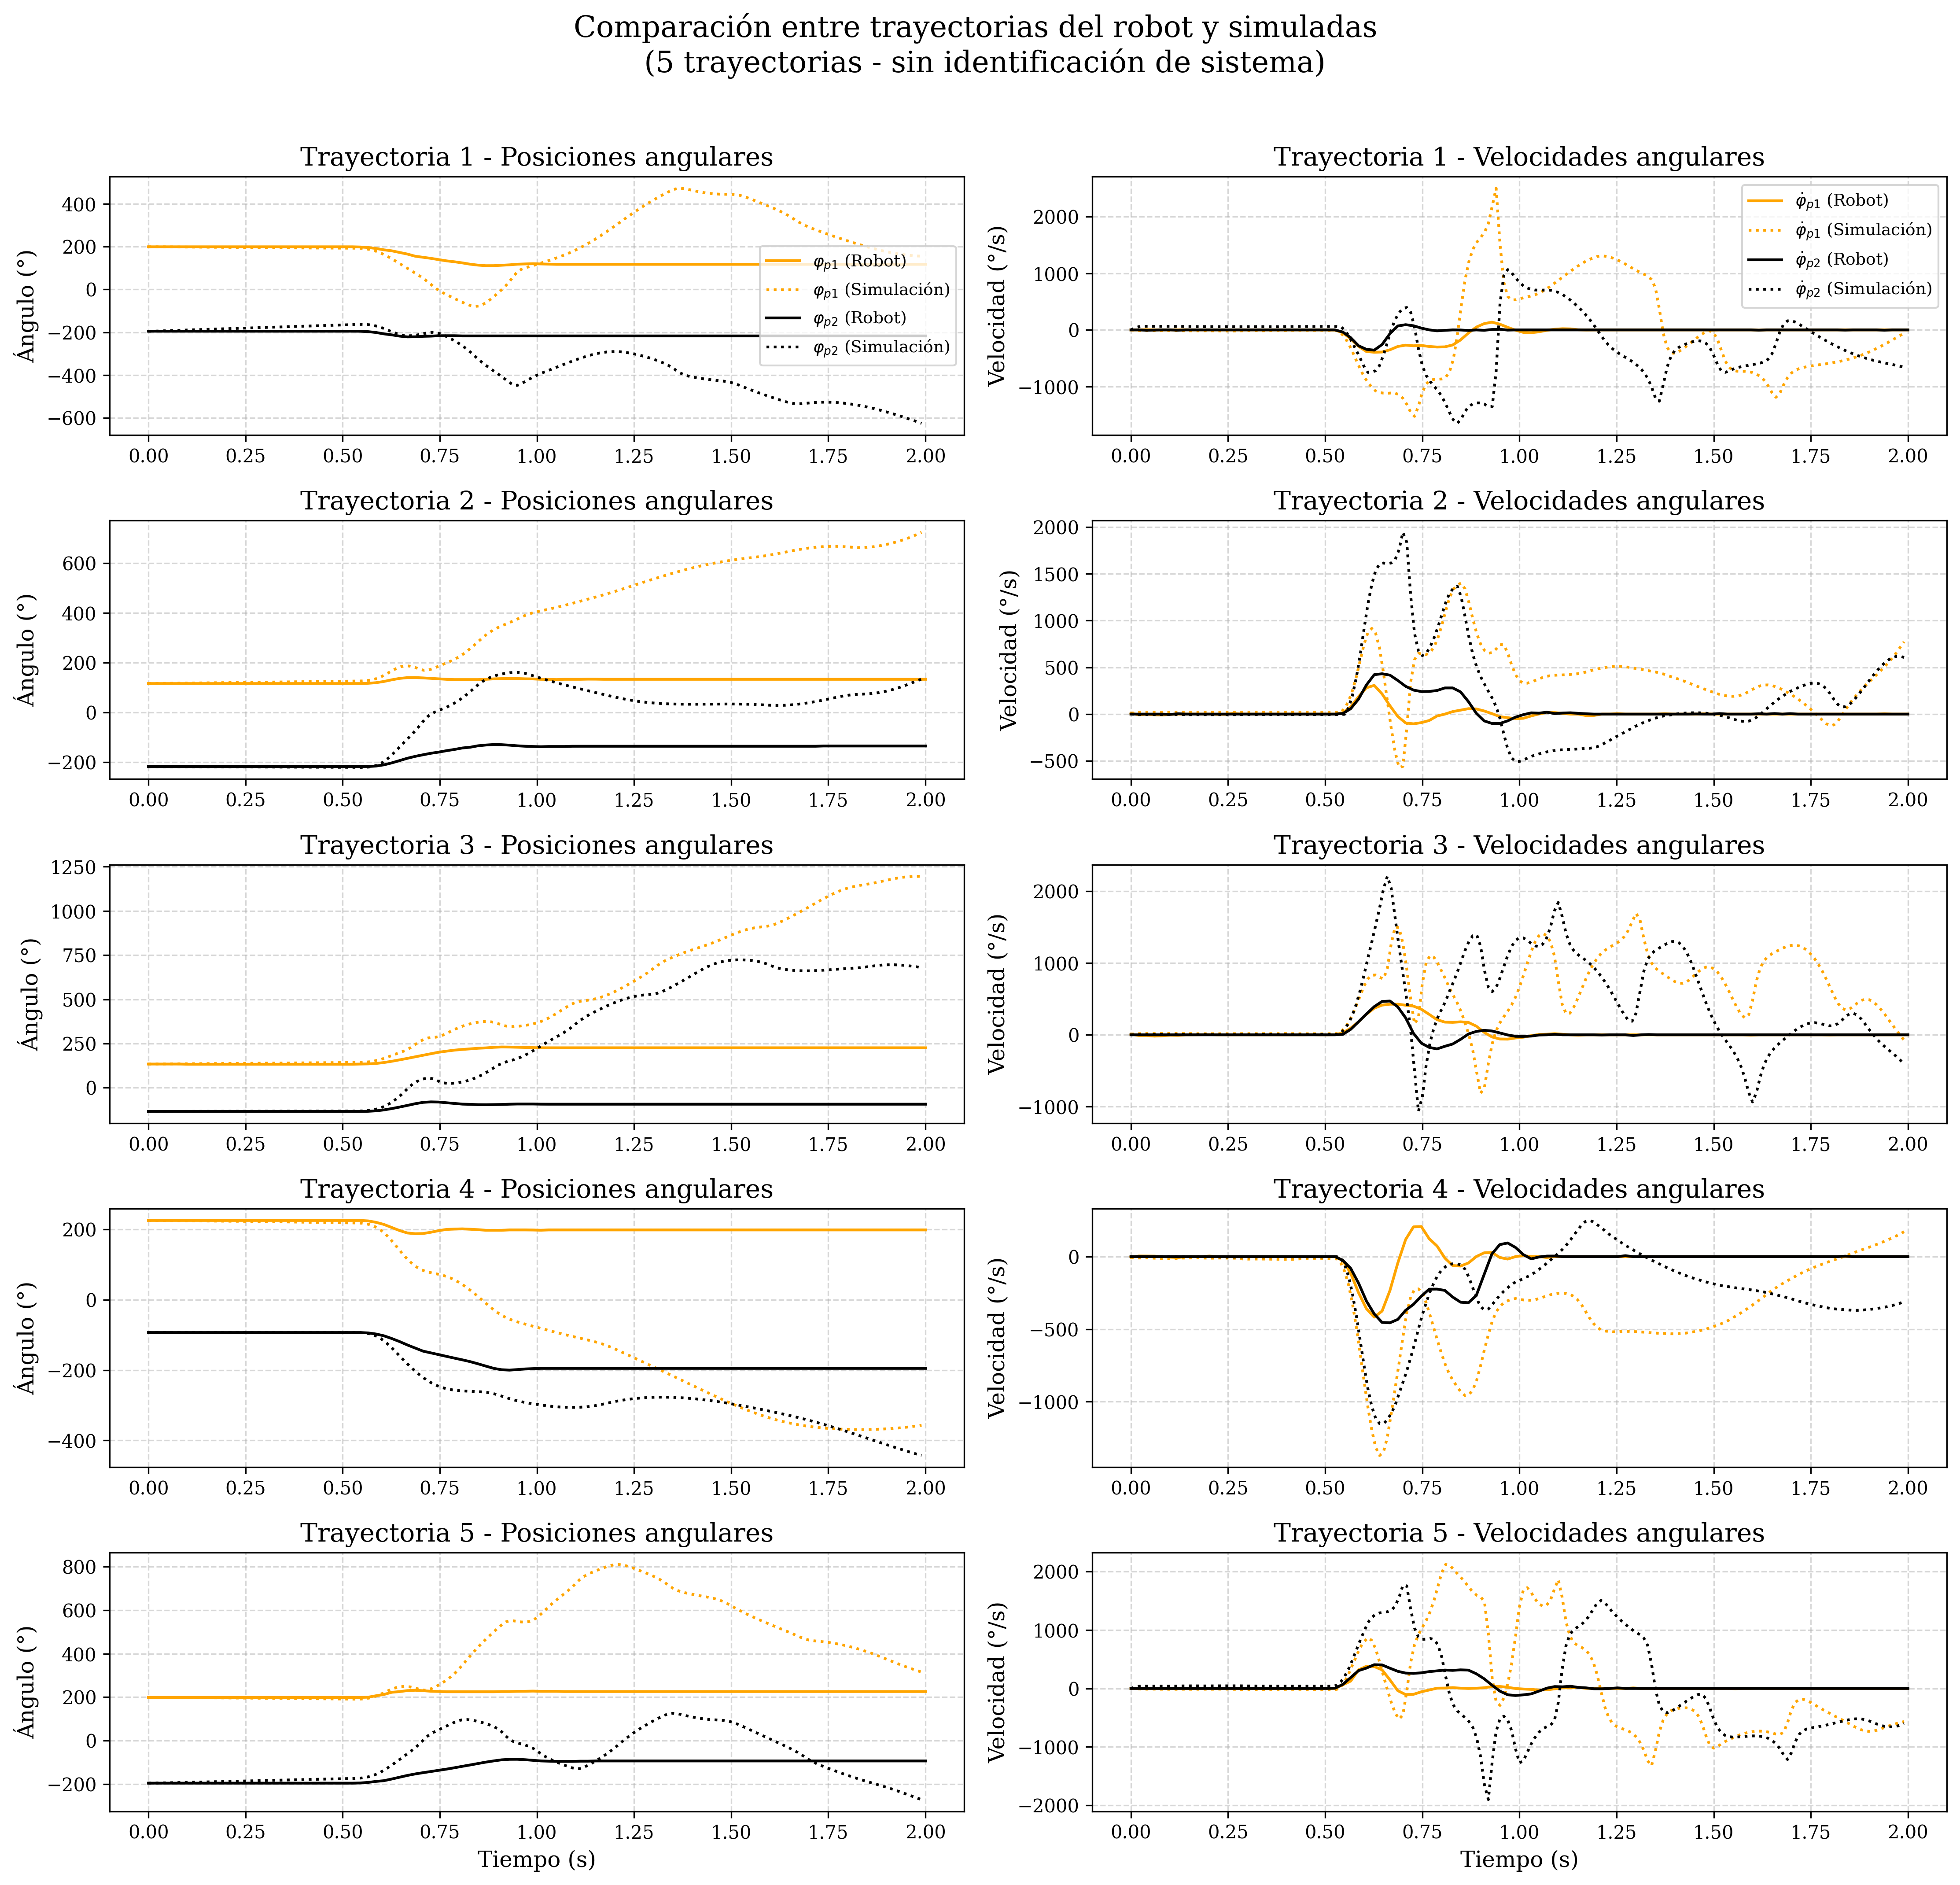

In [65]:
times = np.linspace(0, 2, 100)

fig, axes = plt.subplots(5, 2, figsize=(15, 15))

for i in range(5):
    # --- Posiciones angulares (columna izquierda) ---
    ax_pos = axes[i, 0]
    ax_pos.plot(times, interpolation_fcns[i]["angle1"](times), color='orange', linestyle='-', label=r'$\varphi_{p1}$ (Robot)')
    ax_pos.plot(sim_dataframes[i]["time"], sim_dataframes[i]["angle1"], color='orange', linestyle=':', label=r'$\varphi_{p1}$ (Simulación)')
    ax_pos.plot(times, interpolation_fcns[i]["angle2"](times), color='black', linestyle='-', label=r'$\varphi_{p2}$ (Robot)')
    ax_pos.plot(sim_dataframes[i]["time"], sim_dataframes[i]["angle2"], color='black', linestyle=':', label=r'$\varphi_{p2}$ (Simulación)')
    
    ax_pos.set_ylabel(r'Ángulo (°)')
    ax_pos.set_title(f'Trayectoria {i+1} - Posiciones angulares')
    ax_pos.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax_pos.legend(fontsize=9, loc='best')
    
    # --- Velocidades angulares (columna derecha) ---
    ax_vel = axes[i, 1]
    ax_vel.plot(times, interpolation_fcns[i]["speed1"](times), color='orange', linestyle='-', label=r'$\dot{\varphi}_{p1}$ (Robot)')
    ax_vel.plot(sim_dataframes[i]["time"], sim_dataframes[i]["speed1"], color='orange', linestyle=':', label=r'$\dot{\varphi}_{p1}$ (Simulación)')
    ax_vel.plot(times, interpolation_fcns[i]["speed2"](times), color='black', linestyle='-', label=r'$\dot{\varphi}_{p2}$ (Robot)')
    ax_vel.plot(sim_dataframes[i]["time"], sim_dataframes[i]["speed2"], color='black', linestyle=':', label=r'$\dot{\varphi}_{p2}$ (Simulación)')
    
    ax_vel.set_ylabel(r'Velocidad (°/s)')
    ax_vel.set_title(f'Trayectoria {i+1} - Velocidades angulares')
    ax_vel.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax_vel.legend(fontsize=9, loc='best')

# Etiqueta para eje x en la última fila
for col in range(2):
    axes[-1, col].set_xlabel('Tiempo (s)')

# Ajustar espacio
fig.suptitle('Comparación entre trayectorias del robot y simuladas \n (5 trayectorias - sin identificación de sistema)',fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [40]:
offset_p=-1e-3
offset_d=0

inertia_p=0.00038976
inertia_d=0.00158076

dry_friction_pd=0.25
damping_pd=0

dry_friction_motor1=0.25
dry_friction_motor2=0.25

damping_motor1=0
damping_motor2=0

inertia_rotor=0.0003271

x_0=[offset_p,
     offset_d,
     
     inertia_p,
     inertia_d,
     inertia_rotor,
     
     dry_friction_pd,
     dry_friction_motor1,
     dry_friction_motor2,
     damping_pd,
     
     damping_motor1,
     damping_motor2]

bounds = [(-0.01, 0.01),
          (-0.01, 0.01),
          
          (0.0001, 0.01),
          (0.0001, 0.01),
          (0.0001, 0.01),
          
          (0, 1),
          (0, 1),
          (0, 1),
          
          (0, 1),
          (0, 1),
          (0, 1)] 

def objective(x):
    
    #print("Evaluating...",x)
    xml=simplified_xml(x[0],x[1],x[2],x[3],x[4],x[5],x[6],x[7],x[8],x[9],x[10])

    model = mj.MjModel.from_xml_string(xml)
    data = mj.MjData(model)

    duration = 2

    errors=[]

    for fcns in interpolation_fcns:
        
        mj.mj_resetData(model, data)
    
        theta1_0=np.deg2rad(fcns["angle1"](0))
        theta2_0=np.deg2rad(fcns["angle2"](0))
        
        dtheta1_0=np.deg2rad(fcns["speed1"](0))
        dtheta2_0=np.deg2rad(fcns["speed2"](0))

        theta3_0,theta4_0,dtheta3_0,dtheta4_0=distal_relative_angles_from_proximal(q_base,theta1_0,theta2_0,dtheta1_0,dtheta2_0)
        
        data.qpos[0] = theta1_0
        data.qpos[2] = theta2_0
        
        data.qpos[1] = theta3_0
        data.qpos[3] = theta4_0
        
        data.qvel[0] = dtheta1_0
        data.qvel[2] = dtheta2_0
        
        data.qvel[1] = dtheta3_0
        data.qvel[3] = dtheta4_0

        mj.mj_forward(model, data)

        while data.time < duration:
            errors.append(np.rad2deg(data.qpos[0])-fcns["angle1"](data.time))
            errors.append(np.rad2deg(data.qpos[2])-fcns["angle2"](data.time))
            errors.append(np.rad2deg(data.qvel[0])-fcns["speed1"](data.time))
            errors.append(np.rad2deg(data.qvel[2])-fcns["speed2"](data.time))


            data.ctrl[0]=fcns["torque1"](data.time)
            data.ctrl[1]=fcns["torque2"](data.time)

            mj.mj_step(model, data)

    
    squared_errors=[err**2 for err in errors]
    
    mse = np.mean(squared_errors)
    print("Evaluated: ",mse)
    return mse

In [41]:
def track_iterations(xk):
    val = objective(xk)
    
    print(f"Iteration: x = {xk}, objective = {val}")
result = minimize(objective, x_0, method='L-BFGS-B', bounds=bounds,options={'disp': True},callback=track_iterations)

timestep=0.01
o1x=-0.0375
o1y=0.0
o2x=0.0375
o2y=0.0
L_p1=0.1
L_p2=0.1
L_d1=0.2
L_d2=0.2
link_width=0.02
link_height=0.026
link_separation=0.003
rotor1_D=0.089
rotor2_D=0.089
rotor1_H=0.028
rotor2_H=0.028
max_torque=1.6
q0=[2.356194490192345, 0.999107158546108, -0.999107158546108, -2.356194490192345]
inertia_rotor1=0.0003271
inertia_rotor2=0.0003271
inertia_p1=0.00038976
inertia_p2=0.00038976
inertia_d1=0.00158076
inertia_d2=0.00158076
com_offset_p1=-0.001
com_offset_p2=0.001
com_offset_d1=0.0
com_offset_d2=-0.0
mass_rotor1=0.65
mass_rotor2=0.65
mass_p1=0.1472
mass_p2=0.1472
mass_d1=0.1934
mass_d2=0.1934
damping_bp1=0.0
damping_bp2=0.0
damping_p1d1=0.0
damping_p2d2=0.0
dryfrict_bp1=0.25
dryfrict_bp2=0.25
dryfrict_p1d1=0.25
dryfrict_p2d2=0.25
Evaluated:  7081.698744453665
timestep=0.01
o1x=-0.0375
o1y=0.0
o2x=0.0375
o2y=0.0
L_p1=0.1
L_p2=0.1
L_d1=0.2
L_d2=0.2
link_width=0.02
link_height=0.026
link_separation=0.003
rotor1_D=0.089
rotor2_D=0.089
rotor1_H=0.028
rotor2_H=0.028
max_torque=1.

In [66]:
stri="offset_p,offset_d,inertia_p,inertia_d,inertia_rotor,dry_friction_pd,dry_friction_motor1,dry_friction_motor2,damping_pd,damping_motor1,damping_motor2"
names=stri.split(",")
for i in range(len(result.x)):
    print(names[i]+"="+str(result.x[i]))

offset_p=0.009983792328812793
offset_d=0.01
inertia_p=0.003843877875087692
inertia_d=0.001976203096163032
inertia_rotor=0.003840959321297769
dry_friction_pd=0.043860858060209916
dry_friction_motor1=0.059202867326391774
dry_friction_motor2=0.05598676942548574
damping_pd=0.0
damping_motor1=0.002396319659251412
damping_motor2=0.010065623129392978


In [67]:
offset_p,offset_d,inertia_p,inertia_d,inertia_rotor,dry_friction_pd,dry_friction_motor1,dry_friction_motor2,damping_pd,damping_motor1,damping_motor2=tuple(result.x)


xml=simplified_xml(offset_p,offset_d,inertia_p,inertia_d,inertia_rotor,dry_friction_pd,dry_friction_motor1,dry_friction_motor2,damping_pd,damping_motor1,damping_motor2)

model = mj.MjModel.from_xml_string(xml)
data = mj.MjData(model)


# enable joint visualization option:
scene_option = mj.MjvOption()
cam = mj.MjvCamera()
cam.type = mj.mjtCamera.mjCAMERA_FREE
cam.fixedcamid = -1  # Free camera mode
cam.distance = 0.75   # Distance from lookat point
cam.azimuth = 90      # Rotation around vertical axis (0 for straight)
cam.elevation = -90  # -90 looks straight down
cam.lookat = np.array([0.0, 0.0, 0.0])

duration = 2  # (seconds)
framerate = 60  # (Hz)

sim_dataframes=[]

for fcns in interpolation_fcns:
    # Simulate and display video.
    frames = []
    mj.mj_resetData(model, data)
    
    theta1_0=np.deg2rad(fcns["angle1"](0))
    theta2_0=np.deg2rad(fcns["angle2"](0))
    
    dtheta1_0=np.deg2rad(fcns["speed1"](0))
    dtheta2_0=np.deg2rad(fcns["speed2"](0))

    theta3_0,theta4_0,dtheta3_0,dtheta4_0=distal_relative_angles_from_proximal(q_base,theta1_0,theta2_0,dtheta1_0,dtheta2_0)
    
    data.qpos[0] = theta1_0
    data.qpos[2] = theta2_0
    
    data.qpos[1] = theta3_0
    data.qpos[3] = theta4_0
    
    data.qvel[0] = dtheta1_0
    data.qvel[2] = dtheta2_0
    
    data.qvel[1] = 0
    data.qvel[3] = 0

    mj.mj_forward(model, data)

    sim_df=pd.DataFrame(columns=['time', 'angle1', 'angle2','speed1','speed2'])

    with mj.Renderer(model) as renderer:
        while data.time < duration:

            new_row = {
            'time': data.time,
            'angle1': np.rad2deg(data.qpos[0]),
            'angle2': np.rad2deg(data.qpos[2]),
            'speed1': np.rad2deg(data.qvel[0]),
            'speed2': np.rad2deg(data.qvel[2])
            }

            sim_df.loc[len(sim_df)]=new_row

            data.ctrl[0]=fcns["torque1"](data.time)
            data.ctrl[1]=fcns["torque2"](data.time)
            mj.mj_step(model, data)

            if len(frames) < data.time * framerate:
                renderer.update_scene(data, scene_option=scene_option, camera=cam)
                pixels = renderer.render()
                frames.append(pixels)
    sim_dataframes.append(sim_df)
    #media.show_video(frames, fps=framerate)


timestep=0.01
o1x=-0.0375
o1y=0.0
o2x=0.0375
o2y=0.0
L_p1=0.1
L_p2=0.1
L_d1=0.2
L_d2=0.2
link_width=0.02
link_height=0.026
link_separation=0.003
rotor1_D=0.089
rotor2_D=0.089
rotor1_H=0.028
rotor2_H=0.028
max_torque=1.6
q0=[2.356194490192345, 0.999107158546108, -0.999107158546108, -2.356194490192345]
inertia_rotor1=0.003840959321297769
inertia_rotor2=0.003840959321297769
inertia_p1=0.003843877875087692
inertia_p2=0.003843877875087692
inertia_d1=0.001976203096163032
inertia_d2=0.001976203096163032
com_offset_p1=0.009983792328812793
com_offset_p2=-0.009983792328812793
com_offset_d1=0.01
com_offset_d2=-0.01
mass_rotor1=0.65
mass_rotor2=0.65
mass_p1=0.1472
mass_p2=0.1472
mass_d1=0.1934
mass_d2=0.1934
damping_bp1=0.002396319659251412
damping_bp2=0.010065623129392978
damping_p1d1=0.0
damping_p2d2=0.0
dryfrict_bp1=0.059202867326391774
dryfrict_bp2=0.05598676942548574
dryfrict_p1d1=0.043860858060209916
dryfrict_p2d2=0.043860858060209916


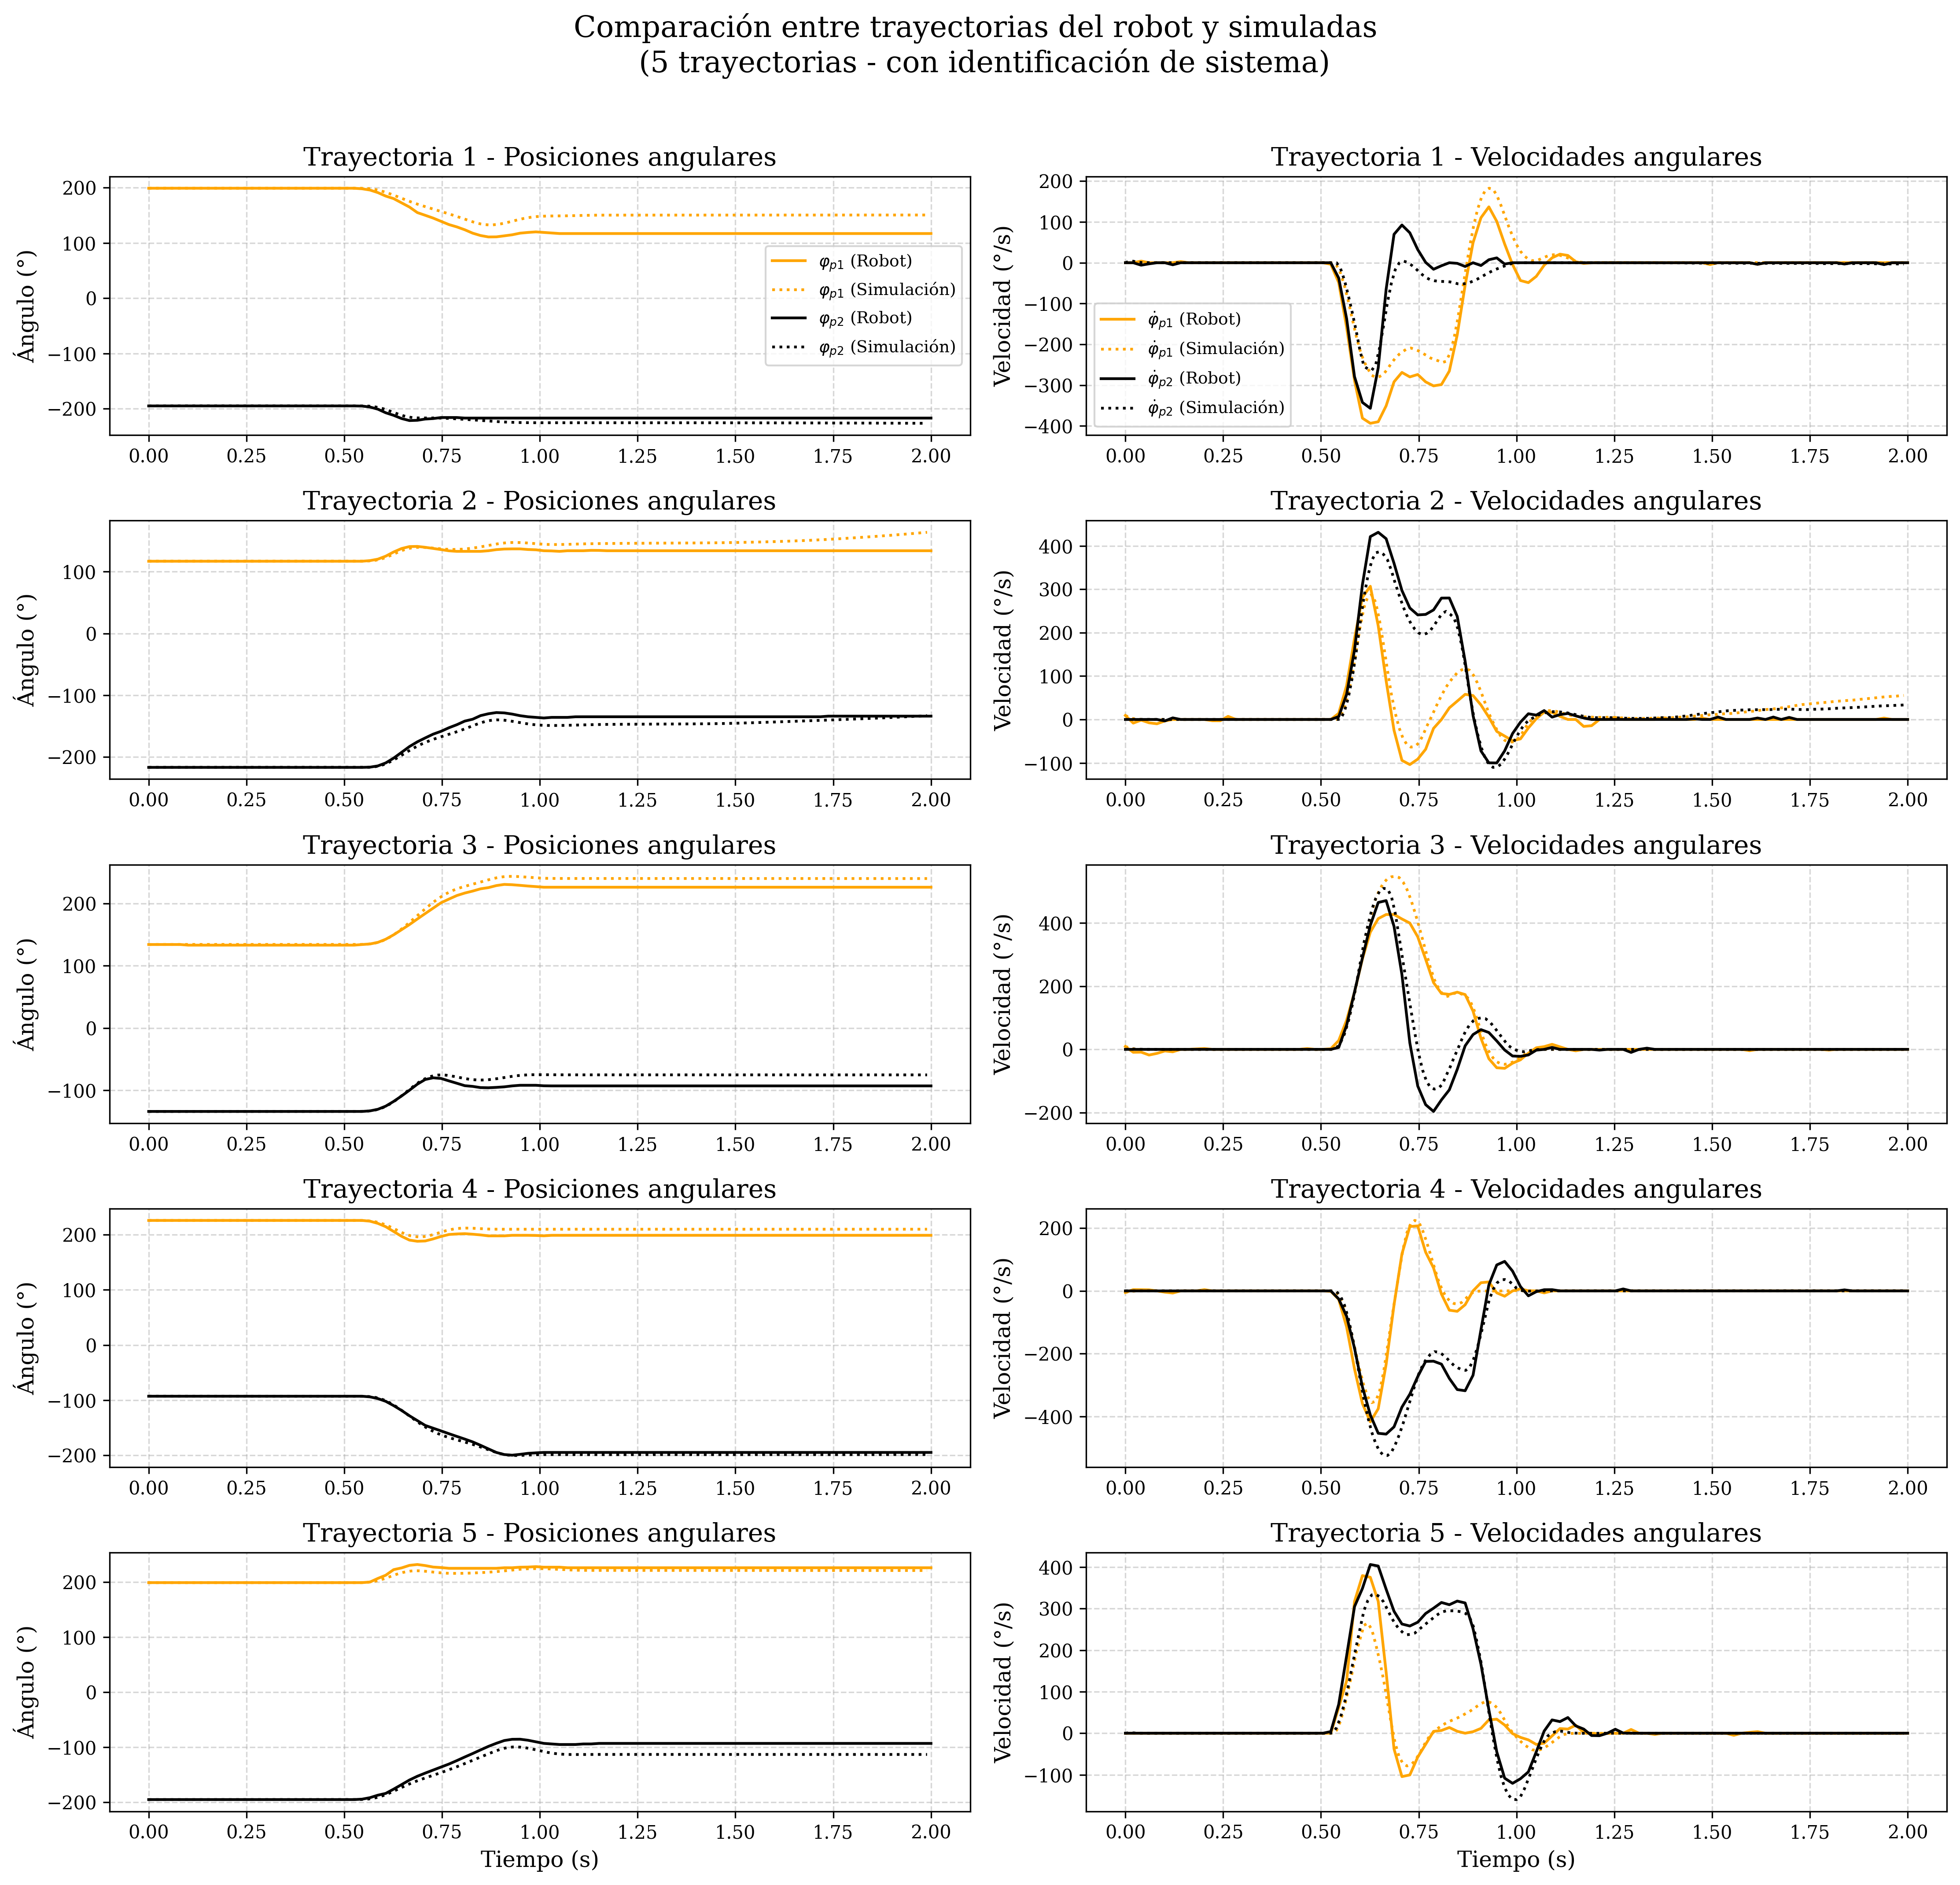

In [69]:
times = np.linspace(0, 2, 100)

fig, axes = plt.subplots(5, 2, figsize=(15, 15))

for i in range(5):
    # --- Posiciones angulares (columna izquierda) ---
    ax_pos = axes[i, 0]
    ax_pos.plot(times, interpolation_fcns[i]["angle1"](times), color='orange', linestyle='-', label=r'$\varphi_{p1}$ (Robot)')
    ax_pos.plot(sim_dataframes[i]["time"], sim_dataframes[i]["angle1"], color='orange', linestyle=':', label=r'$\varphi_{p1}$ (Simulación)')
    ax_pos.plot(times, interpolation_fcns[i]["angle2"](times), color='black', linestyle='-', label=r'$\varphi_{p2}$ (Robot)')
    ax_pos.plot(sim_dataframes[i]["time"], sim_dataframes[i]["angle2"], color='black', linestyle=':', label=r'$\varphi_{p2}$ (Simulación)')
    
    ax_pos.set_ylabel(r'Ángulo (°)')
    ax_pos.set_title(f'Trayectoria {i+1} - Posiciones angulares')
    ax_pos.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax_pos.legend(fontsize=9, loc='best')
    
    # --- Velocidades angulares (columna derecha) ---
    ax_vel = axes[i, 1]
    ax_vel.plot(times, interpolation_fcns[i]["speed1"](times), color='orange', linestyle='-', label=r'$\dot{\varphi}_{p1}$ (Robot)')
    ax_vel.plot(sim_dataframes[i]["time"], sim_dataframes[i]["speed1"], color='orange', linestyle=':', label=r'$\dot{\varphi}_{p1}$ (Simulación)')
    ax_vel.plot(times, interpolation_fcns[i]["speed2"](times), color='black', linestyle='-', label=r'$\dot{\varphi}_{p2}$ (Robot)')
    ax_vel.plot(sim_dataframes[i]["time"], sim_dataframes[i]["speed2"], color='black', linestyle=':', label=r'$\dot{\varphi}_{p2}$ (Simulación)')
    
    ax_vel.set_ylabel(r'Velocidad (°/s)')
    ax_vel.set_title(f'Trayectoria {i+1} - Velocidades angulares')
    ax_vel.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax_vel.legend(fontsize=9, loc='best')

# Etiqueta para eje x en la última fila
for col in range(2):
    axes[-1, col].set_xlabel('Tiempo (s)')

# Ajustar espacio
fig.suptitle('Comparación entre trayectorias del robot y simuladas \n (5 trayectorias - con identificación de sistema)',fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()